In [1]:
import math
import os
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks

In [13]:
data_root = 'data'
user_numbers = ['1', '2']  # matches recorder -u / --user-number
task_performed_values = ['roll', 'pitch', 'yaw']  # matches recorder -t / --task-performed
diameter_mm = 80  # matches recorder -s / --diameter-mm
trial_numbers = ['1', '2', '3', '4', '5']  # matches recorder -tn / --trial-number

USER = user_numbers  
USERCOLOR = ['red', 'blue', 'turquoise', 'olive']
ROTAXIS = task_performed_values  ## yaw, pitch, roll
DIAMETER = diameter_mm  ## 50 or 80
LINESTYLES = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3,1,1,1,1,1))]
MARKERSTYLES = ['o', 's', 'D', '^', 'v']
TOTALTRIALS = len(trial_numbers)
data_dir_dict = {}
pca_dict = {}
PCACOMPONENTS = ['components', 'variance', 'variance_ratio']
PCAFEATURES = [
    "Thumb Grav","Index Grav","Ring Grav",
    "Thumb Lateral","Index Lateral","Ring Lateral",
    "Thumb Normal", "Index Normal", "Ring Normal",
]
PCAORDER = [0,6,3,1,7,4,2,8,5]
PCADIM = len(PCAFEATURES)


def get_trial_dir(data_root, user_number, diameter_mm, task_performed, trial_number):
    return os.path.join(
        data_root,
        f'user_{user_number}',
        f'{diameter_mm}mm',
        task_performed,
        f'trial_{trial_number}',
    )


for rot in ROTAXIS:
    data_dir_dict[rot]  = {}
    pca_dict[rot] = {}
    for usrs in USER:
        data_dir_dict[rot][usrs] = [
            get_trial_dir(data_root, usrs, DIAMETER, rot, trial_number)
            for trial_number in trial_numbers
        ]
        pca_dict[rot][usrs] = {}
        for pca_comp in PCACOMPONENTS:
            pca_dict[rot][usrs][pca_comp] = []


# Function Libs

In [3]:
def quick_visualization(data):

    max_val = np.max(data)
    min_val = np.min(data)

    up_bound = max_val * 1.2
    low_bound = min_val * 1.2

    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(311)
    ax1.plot(data[:, 0])
    ax1.plot(data[:, 1])
    ax1.plot(data[:, 2])
    ax1.set_title(f'Force Data - Thumb')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Force (N)')
    ax1.legend(['Fx', 'Fy', 'Fz'])
    ax1.set_ylim(low_bound, up_bound)

    ax2 = fig.add_subplot(312)
    ax2.plot(data[:, 3])
    ax2.plot(data[:, 4])
    ax2.plot(data[:, 5])
    ax2.set_title(f'Force Data - Ring')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Force (N)')
    ax2.legend(['Fx', 'Fy', 'Fz'])
    ax2.set_ylim(low_bound, up_bound)

    ax3 = fig.add_subplot(313)
    ax3.plot(data[:, 6])
    ax3.plot(data[:, 7])
    ax3.plot(data[:, 8])
    ax3.set_title(f'Force Data - Index')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('Force (N)')
    ax3.legend(['Fx', 'Fy', 'Fz'])
    ax3.set_ylim(low_bound, up_bound)
    
    plt.tight_layout()
    plt.show()

In [4]:
def load_single_trial(data_dir):
    thumb_path = os.path.join(data_dir, 'thumb.csv')
    ring_path = os.path.join(data_dir, 'middle.csv')
    index_path = os.path.join(data_dir, 'index.csv')

    missing_files = [
        path for path in [thumb_path, ring_path, index_path]
        if not os.path.exists(path)
    ]
    if missing_files:
        raise FileNotFoundError(
            'Missing recorder CSV file(s): ' + ', '.join(missing_files)
        )

    thumb = pd.read_csv(thumb_path)
    ring = pd.read_csv(ring_path)
    index = pd.read_csv(index_path)

    n_samples = min(len(thumb), len(ring), len(index))
    if n_samples == 0:
        raise ValueError(
            f'One or more finger CSVs are empty in {data_dir}. '
            f'Rows: thumb={len(thumb)}, middle={len(ring)}, index={len(index)}'
        )

    return np.column_stack([
        thumb[['Fx', 'Fy', 'Fz']].to_numpy(dtype=float)[:n_samples],
        ring[['Fx', 'Fy', 'Fz']].to_numpy(dtype=float)[:n_samples],
        index[['Fx', 'Fy', 'Fz']].to_numpy(dtype=float)[:n_samples],
    ])


def load_data(data_dir_lis, visualize = False):
    data_lis_arr = []
    for data_dir in data_dir_lis:
        data = load_single_trial(data_dir)
        if visualize:
            quick_visualization(data)
        data_lis_arr.append(data)
    
    return data_lis_arr


In [5]:
def pca_analysis(data, n_components=PCADIM):
    pca = PCA(n_components=n_components)
    pca.fit_transform(data)
    return pca.components_, pca.explained_variance_, pca.explained_variance_ratio_

In [6]:
def data_process(data_dir_dict, pca_dict, visualize_flag=False):
    for rot in ROTAXIS:
        for usrs in USER:
            data_lis = data_dir_dict[rot][usrs]
            data_lis_arr = load_data(data_lis, visualize=visualize_flag)
            for data in data_lis_arr:
                components, variance, variance_ratio = pca_analysis(data)
                pca_dict[rot][usrs]['components'].append(components)
                pca_dict[rot][usrs]['variance'].append(variance)
                pca_dict[rot][usrs]['variance_ratio'].append(variance_ratio)
    return

In [7]:
def pca_data_analysis(pca_dict):
    for rot in ROTAXIS:
        for usrs in USER:
            print(f'User: {usrs.capitalize()}, Rotation Axis: {rot.capitalize()}')
            ratio_dict = {}
            for i in range(PCADIM):
                ratio_dict[i] = []

            for i in range(PCADIM):
                for j in range(TOTALTRIALS):
                    ratio = pca_dict[rot][usrs]['variance_ratio'][j][i]
                    ratio_dict[i].append(ratio)

            for i in range(PCADIM):
                mean_ratio = np.mean(ratio_dict[i])
                std_ratio = np.std(ratio_dict[i])
                print(f'PC{i+1}: {mean_ratio:.2%} ± {std_ratio:.2%}')

    return

In [8]:
def data_axis_sorting(pca_dict):
    for rot in ROTAXIS:
        for z,usrs in enumerate(USER):
            pca_trials_dict = {}
            max_feature_idx = []
            for j in range(PCADIM):
                pca_trials_dict[j] = []
            for i in range(TOTALTRIALS):
                for j in range(PCADIM):
                    pca_trials_dict[j].append(pca_dict[rot][usrs]['components'][i][j])
            for j in range(PCADIM):
                pca_trials_dict[j] = np.array(pca_trials_dict[j]).reshape(TOTALTRIALS, -1)
                mean_component = np.mean(abs(pca_trials_dict[j]), axis=0)
                max_idx = np.argmax(mean_component)
                max_feature_idx.append(max_idx)

            for i in range(TOTALTRIALS):
                for j in range(PCADIM):
                    if pca_dict[rot][usrs]['components'][i][j][max_feature_idx[j]] < 0:
                        pca_dict[rot][usrs]['components'][i][j] = -pca_dict[rot][usrs]['components'][i][j]
    return pca_dict

In [9]:
def data_plotting(pca_dict, all_trials_flag=False):
    pca_dict = data_axis_sorting(pca_dict)
    for rot in ROTAXIS:
        figure, axes = plt.subplots(PCADIM, 1, figsize=(12, 3 * PCADIM))
        for ax in axes:
            ax.set_ylim(-1, 1)
            ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
        for z,usrs in enumerate(USER):
            user_num = z + 1

            if all_trials_flag:
                for i in range(TOTALTRIALS):
                    components = pca_dict[rot][usrs]['components'][i]
                    variance = pca_dict[rot][usrs]['variance'][i]
                    variance_ratio = pca_dict[rot][usrs]['variance_ratio'][i]
                    components_new = components[:, PCAORDER]
                    # components_new = abs(components[:, PCAORDER])
                    for j in range(components.shape[0]):
                        axes[j].plot(components_new[j], label=f'User {user_num}' if i==0 else None, color=USERCOLOR[z], linestyle=LINESTYLES[i])
                        axes[j].scatter(range(PCADIM), components_new[j], color=USERCOLOR[z], marker=MARKERSTYLES[i], s=20, edgecolors='black', zorder=5)
                        axes[j].set_xticks(range(PCADIM))
                        axes[j].set_xticklabels(PCAFEATURES)
                        if z == len(USER) - 1:
                            axes[j].set_ylabel(f'PC{j+1}')
                            if j == 0:
                                axes[j].set_title(f'{rot.capitalize()}')
                        axes[j].legend()
            else:
                pca_means = []
                pca_stds = []
                pca_trials = {}
                for j in range(PCADIM):
                    pca_trials[j] = []
                    for i in range(TOTALTRIALS):
                        pca_trials[j].append(pca_dict[rot][usrs]['components'][i][j])
                    pca_trials[j] = np.array(pca_trials[j]).reshape(TOTALTRIALS, -1)
                    mean_pca = np.mean(pca_trials[j], axis=0)
                    std_pca = np.std(pca_trials[j], axis=0)
                    pca_means.append(mean_pca)
                    pca_stds.append(std_pca)
                pca_means = np.array(pca_means).reshape(PCADIM, -1)
                pca_stds = np.array(pca_stds).reshape(PCADIM, -1)
                pca_means = pca_means[:, PCAORDER]
                pca_stds = pca_stds[:, PCAORDER]
                for j in range(PCADIM):
                    axes[j].plot(pca_means[j, :], label=f'User {user_num}', color=USERCOLOR[z], linestyle=LINESTYLES[0])
                    axes[j].scatter(range(PCADIM), pca_means[j, :], color=USERCOLOR[z], marker=MARKERSTYLES[0], s=50, edgecolors='black', zorder=5)
                    axes[j].fill_between(range(PCADIM), pca_means[j, :] - pca_stds[j, :], pca_means[j, :] + pca_stds[j, :], color=USERCOLOR[z], alpha=0.2)
                    axes[j].set_xticks(range(PCADIM))
                    axes[j].set_xticklabels(PCAFEATURES)
                    if z == len(USER) - 1:
                        axes[j].set_ylabel(f'PC{j+1}')
                        if j == 0:
                            axes[j].set_title(f'{rot.capitalize()}')
                    axes[j].legend()
    return

# Analysis

In [10]:
data_process(data_dir_dict, pca_dict, False)

/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kyang/miniconda3/envs/finger-manipu/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Us

In [11]:
pca_data_analysis(pca_dict)

User: 1, Rotation Axis: Roll
PC1: 64.47% ± 2.34%
PC2: 21.04% ± 3.86%
PC3: 6.97% ± 1.33%
PC4: 3.09% ± 0.61%
PC5: 1.75% ± 0.36%
PC6: 1.07% ± 0.13%
PC7: 0.80% ± 0.13%
PC8: 0.46% ± 0.08%
PC9: 0.35% ± 0.10%
User: 2, Rotation Axis: Roll
PC1: 48.63% ± 2.90%
PC2: 35.74% ± 3.71%
PC3: 7.18% ± 1.08%
PC4: 4.17% ± 0.80%
PC5: 1.92% ± 0.52%
PC6: 0.94% ± 0.11%
PC7: 0.75% ± 0.19%
PC8: 0.49% ± 0.07%
PC9: 0.18% ± 0.05%
User: 1, Rotation Axis: Pitch
PC1: 63.18% ± 3.48%
PC2: 15.68% ± 0.74%
PC3: 9.17% ± 1.29%
PC4: 5.37% ± 1.14%
PC5: 2.91% ± 0.56%
PC6: 1.65% ± 0.34%
PC7: 1.05% ± 0.22%
PC8: 0.67% ± 0.08%
PC9: 0.33% ± 0.07%
User: 2, Rotation Axis: Pitch
PC1: 72.38% ± 2.93%
PC2: 13.77% ± 1.40%
PC3: 5.95% ± 1.52%
PC4: 3.12% ± 0.47%
PC5: 2.04% ± 0.20%
PC6: 1.14% ± 0.28%
PC7: 0.70% ± 0.07%
PC8: 0.54% ± 0.09%
PC9: 0.36% ± 0.14%
User: 1, Rotation Axis: Yaw
PC1: 68.67% ± 6.36%
PC2: 11.61% ± 4.54%
PC3: 7.19% ± 0.84%
PC4: 5.72% ± 0.45%
PC5: 2.62% ± 0.45%
PC6: 1.71% ± 0.31%
PC7: 1.14% ± 0.32%
PC8: 0.78% ± 0.12%
PC9: 0.5

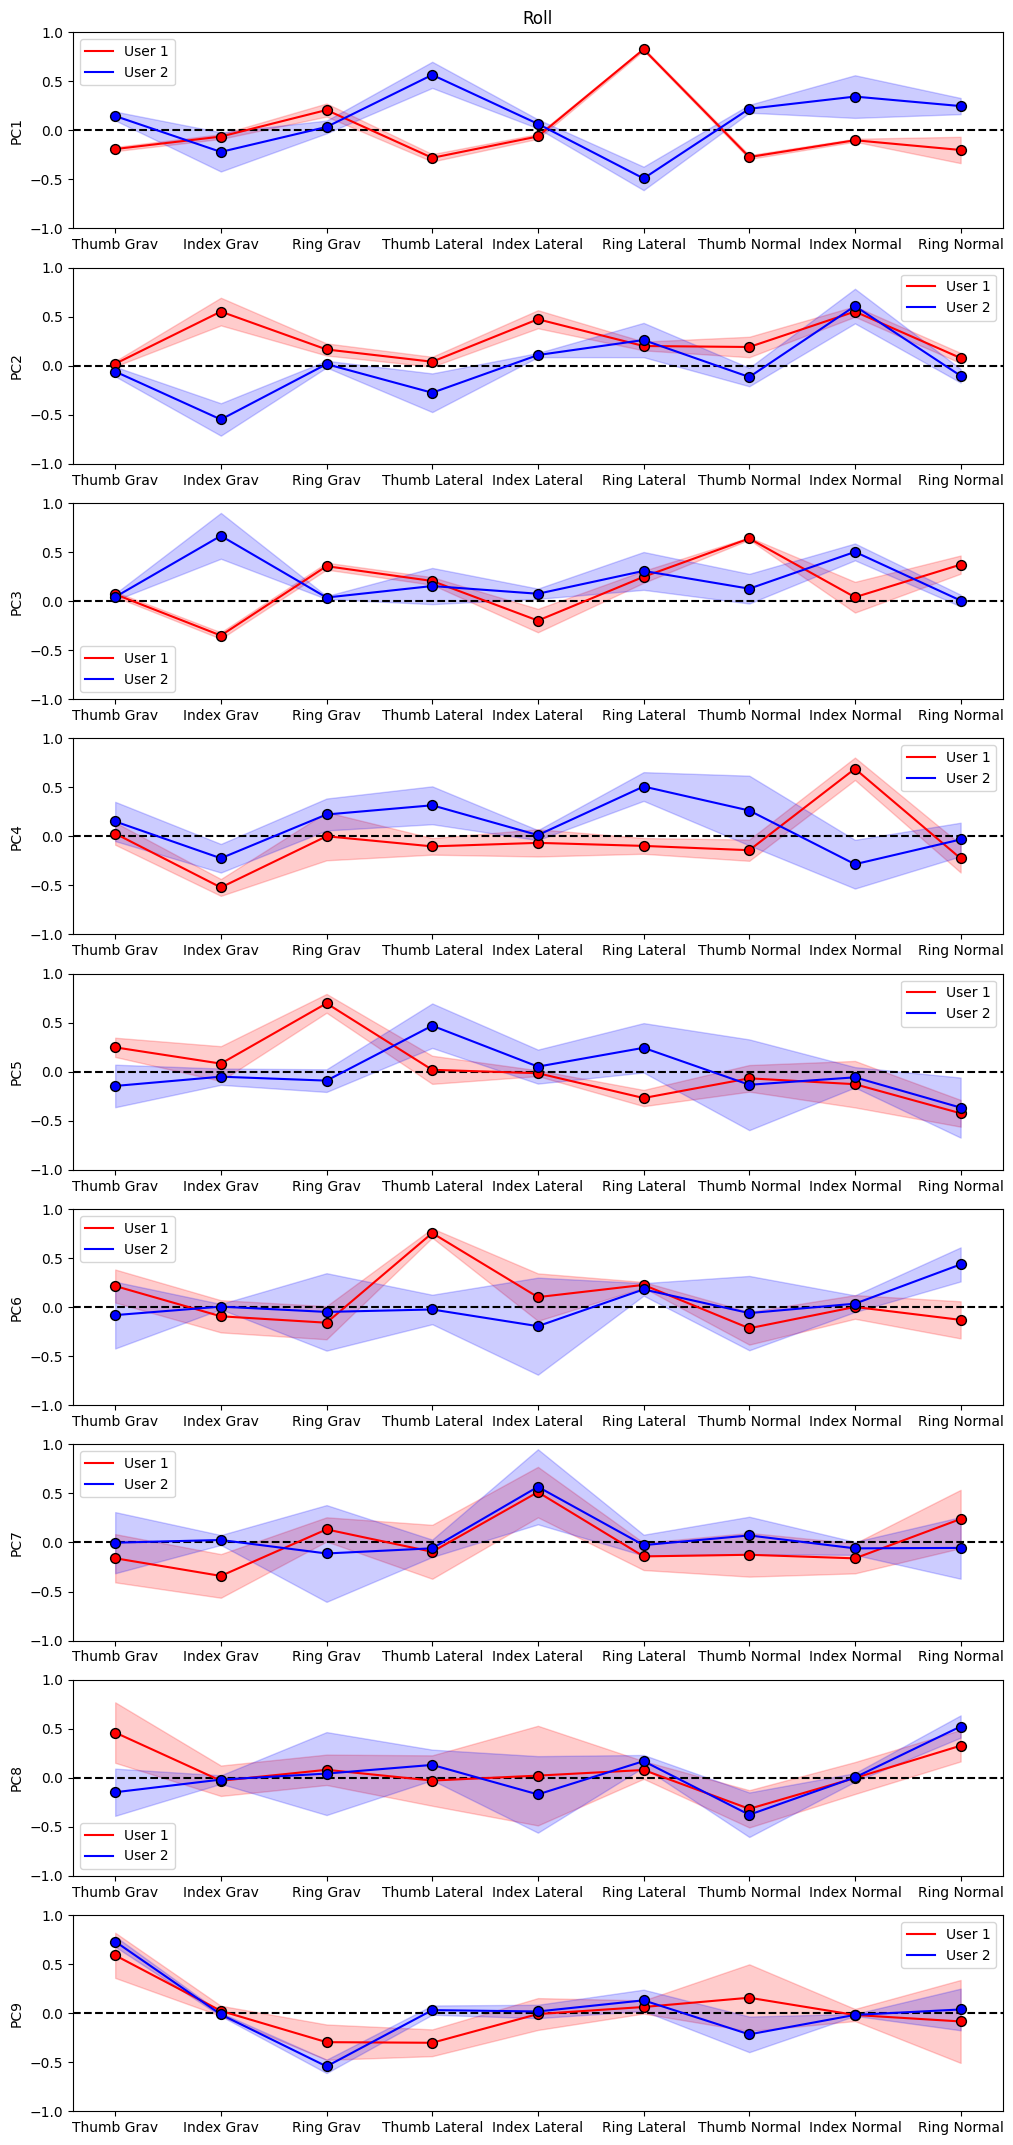

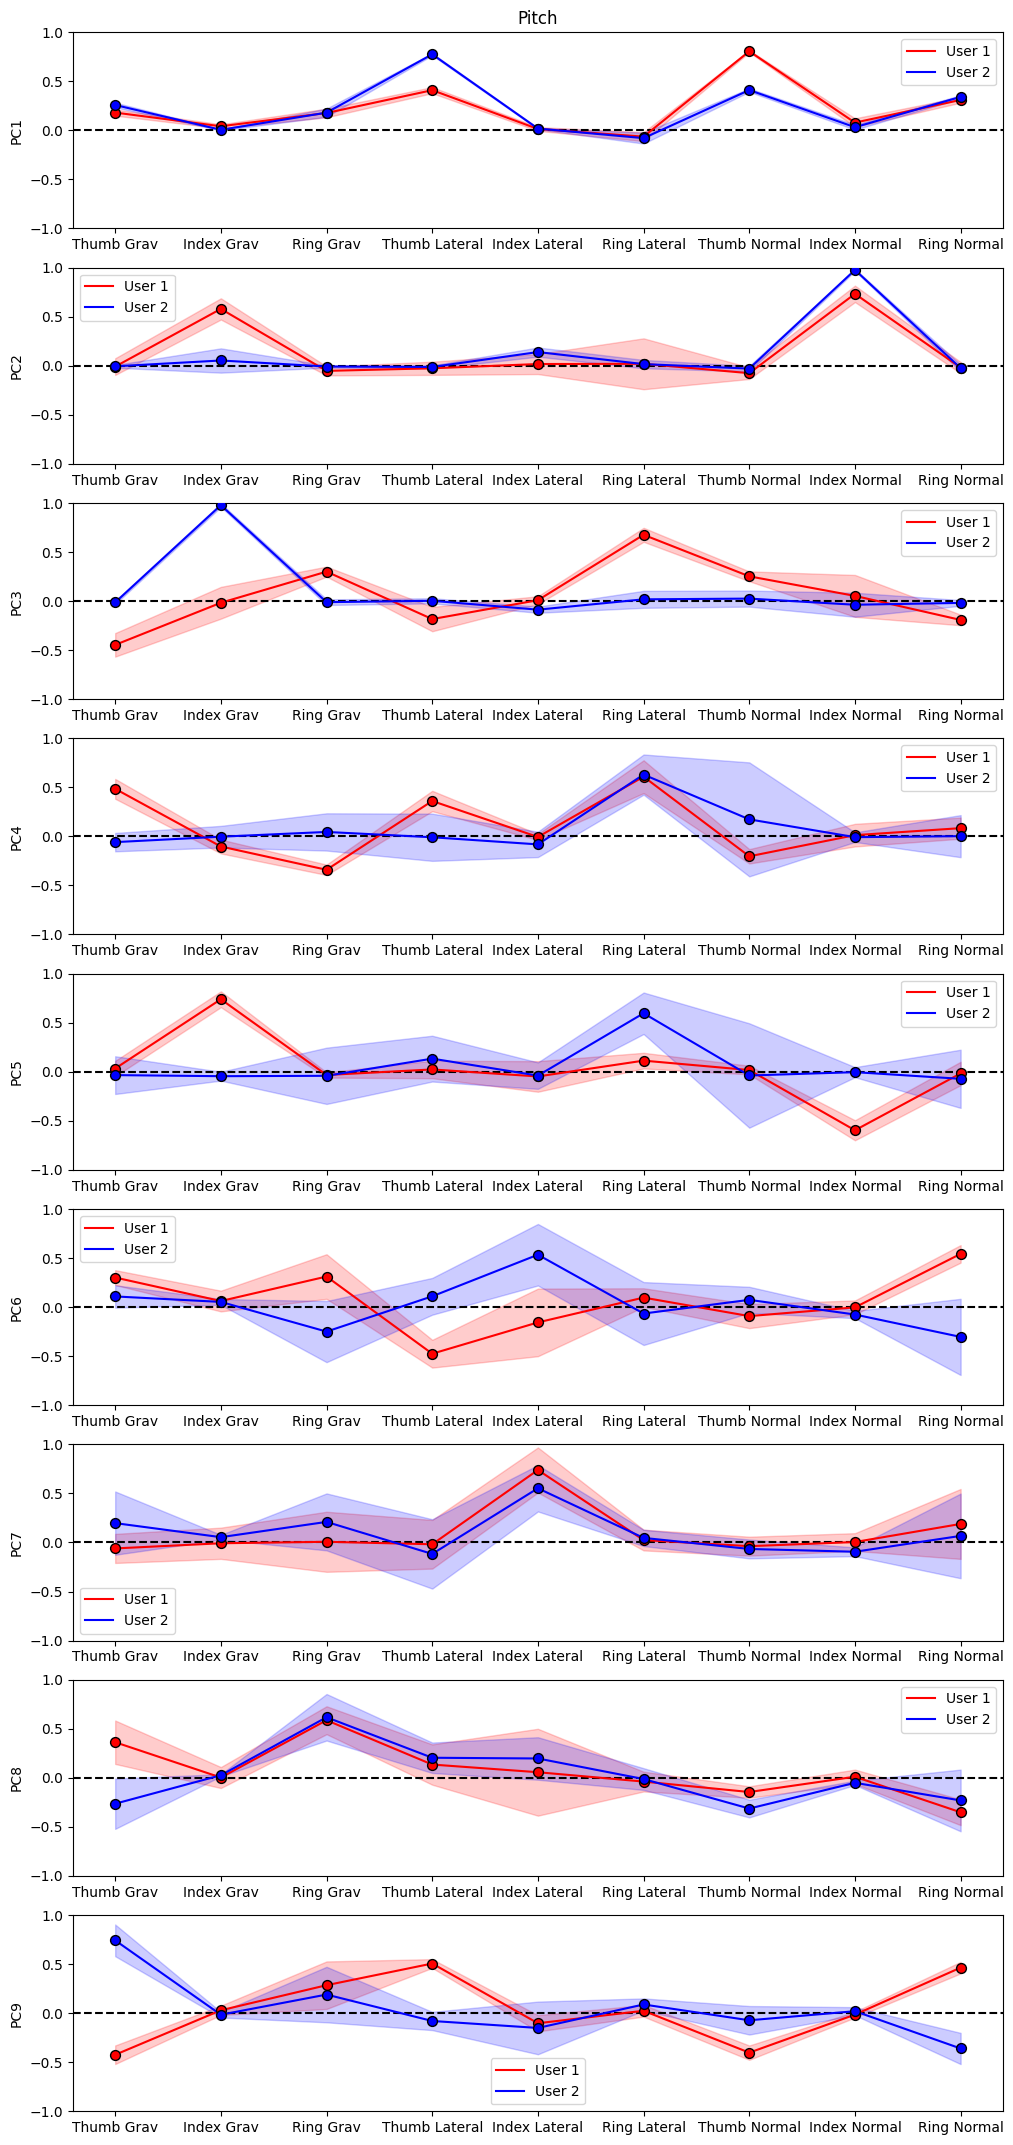

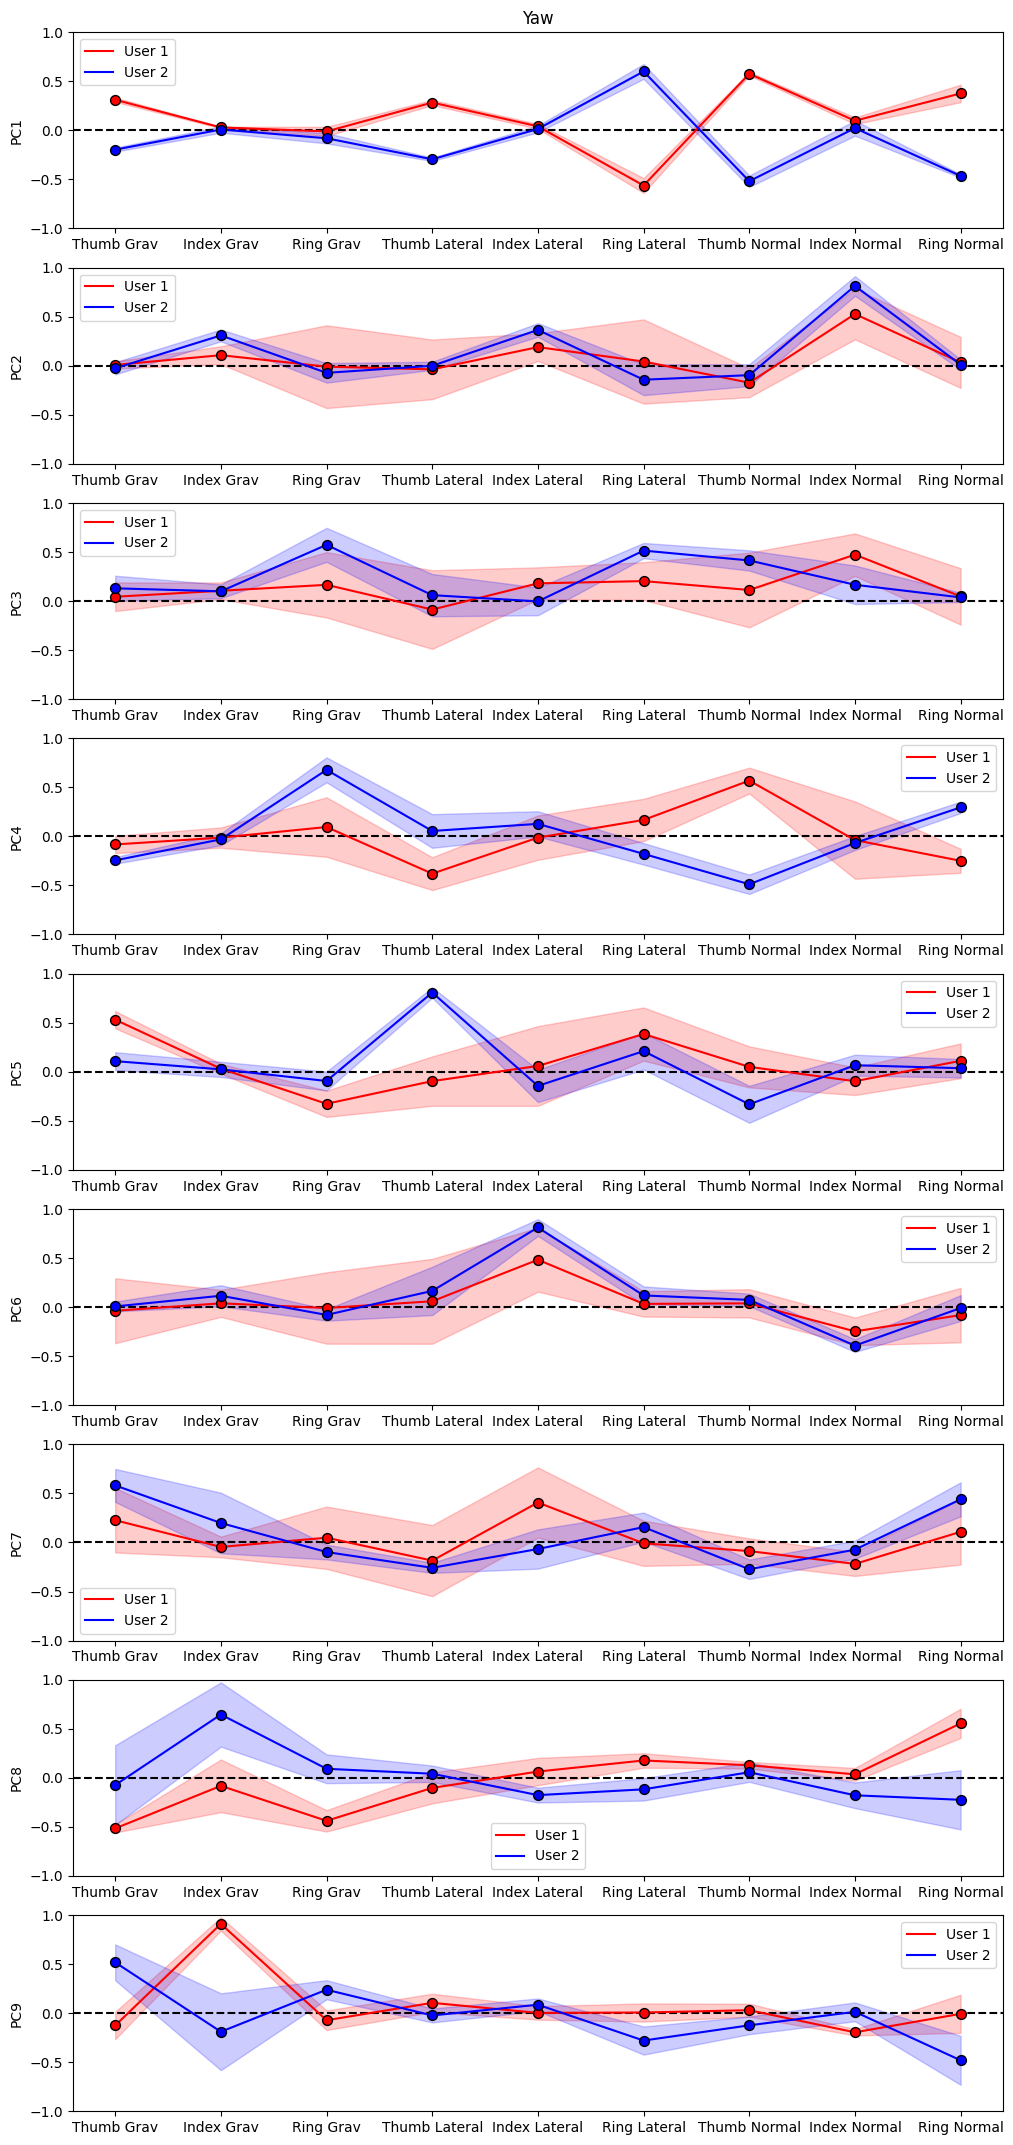

In [12]:
data_plotting(pca_dict, False)